# SME Liquidity GRPO Training on Colab

This notebook follows the same SME liquidity environment.

| Component | Detail |
|-----------|--------|
| Environment | In-process SME liquidity environment from this repo |
| Training | Simple GRPO notebook wrapper |
| Model | `Qwen/Qwen3-0.6B` + LoRA |
| Framework | HF TRL GRPO using the canonical repo training path |

## 1. Install Dependencies

Install the RL dependencies needed for the canonical liquidity trainer.

In [1]:
%pip install -q "trl[vllm]==0.29.0" "vllm>=0.11.0" "transformers>=4.56.0,<4.57.0" "huggingface_hub>=0.34.0,<1.0" "accelerate>=1.0.0" "peft>=0.17.0" bitsandbytes sentencepiece matplotlib datasets

%pip install -q -U pip

from pathlib import Path

REPO_URL = "https://github.com/SkandaGanesha1/OpenEnv_SME_Negotiator-2.o.git"
REPO_DIR = Path("OpenEnv_SME_Negotiator-2.o")

if not REPO_DIR.exists():
    !git clone -q $REPO_URL

%cd $REPO_DIR
%pip install -q -e .[rl]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.0/355.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 105.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 85.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 47.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━

## 2. Configuration

Set the model, environment task, and small profile. This notebook defaults to a T4-safe `tiny` profile.

In [2]:
import os
from pathlib import Path

os.environ.setdefault("TRL_EXPERIMENTAL_SILENCE", "1")

# Uncomment the line below to get synchronous CUDA error messages pointing to the
# exact kernel that failed (makes training ~3× slower — for debugging only):
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

RUN_PROFILE = "tiny"
MODEL_NAME = "Qwen/Qwen3-0.6B"
TASK_NAME = "liquidity-correlation-hard"
DIFFICULTY = "hard"
TOTAL_PERIODS = 2
SEED_BASE = 1000
USE_VLLM = True
VLLM_GPU_MEMORY_UTILIZATION = 0.5
VLLM_MAX_MODEL_LENGTH = 2048
OUTPUT_DIR = Path("outputs/grpo_sme_liquidity_simple")

print(f"Profile     : {RUN_PROFILE}")
print(f"Model       : {MODEL_NAME}")
print(f"Task        : {TASK_NAME}")
print(f"Difficulty  : {DIFFICULTY}")
print(f"Periods     : {TOTAL_PERIODS}")
print(f"Seed base   : {SEED_BASE}")
print(f"Use vLLM    : {USE_VLLM}")
print(f"vLLM KV mem : {VLLM_GPU_MEMORY_UTILIZATION}")
print(f"vLLM max len: {VLLM_MAX_MODEL_LENGTH}")
print(f"Output dir  : {OUTPUT_DIR}")
print("Note        : 'tiny' is a smoke-sized run and will produce a sparse reward curve.")
print("Recommendation: switch to profile='small' or raise num_samples/max_steps for a more meaningful curve.")
print("Backend     : vLLM is required here because the pinned TRL rollout_func path is only wired through the vLLM backend.")


Profile     : tiny
Model       : Qwen/Qwen3-0.6B
Task        : liquidity-correlation-hard
Difficulty  : hard
Periods     : 2
Seed base   : 1000
Use vLLM    : True
vLLM KV mem : 0.5
vLLM max len: 2048
Output dir  : outputs/grpo_sme_liquidity_simple
Note        : 'tiny' is a smoke-sized run and will produce a sparse reward curve.
Recommendation: switch to profile='small' or raise num_samples/max_steps for a more meaningful curve.
Backend     : vLLM is required here because the pinned TRL rollout_func path is only wired through the vLLM backend.


## 3. Import Training Utilities from Package

All notebook logic comes from the repo package. The notebook stays thin and reuses the same Python training functions as the CLI script.

In [3]:
import inspect
import rl.train_grpo_liquidity as liquidity_module

try:
    from rl.train_grpo_liquidity import (
        build_canonical_training_args,
        build_run_plan,
        build_training_session,
        make_training_args,
        plot_rewards,
        run_training,
        smoke_test_environment,
    )
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Could not import rl.train_grpo_liquidity. Run the install/bootstrap cell first so the notebook checks out "
        "the correct repo branch and installs the package in editable mode."
    ) from exc

print(f"Using rl.train_grpo_liquidity from: {Path(inspect.getfile(liquidity_module)).resolve()}")

NOTEBOOK_ARGS = make_training_args(
    profile=RUN_PROFILE,
    model_name=MODEL_NAME,
    task_name=TASK_NAME,
    difficulty=DIFFICULTY,
    total_periods=TOTAL_PERIODS,
    seed_base=SEED_BASE,
    output_dir=str(OUTPUT_DIR),
    use_vllm=USE_VLLM,
    vllm_gpu_memory_utilization=VLLM_GPU_MEMORY_UTILIZATION,
    vllm_max_model_length=VLLM_MAX_MODEL_LENGTH,
)
CANONICAL_ARGS = build_canonical_training_args(NOTEBOOK_ARGS)
RUN_PLAN = build_run_plan(NOTEBOOK_ARGS, CANONICAL_ARGS)

RUN_PLAN


Using rl.train_grpo_liquidity from: /kaggle/working/OpenEnv_SME_Negotiator-2.o/rl/train_grpo_liquidity.py


{'profile': 'tiny',
 'task': {'model_name': 'Qwen/Qwen3-0.6B',
  'task_name': 'liquidity-correlation-hard',
  'difficulty': 'hard',
  'total_periods': 2,
  'seed_base': 1000},
 'training': {'runtime_backend': 'environment',
  'num_samples': 8,
  'max_steps': 4,
  'max_episode_steps': 8,
  'num_generations': 4,
  'gradient_accumulation_steps': 4,
  'learning_rate': 5e-06,
  'max_completion_length': 256,
  'use_vllm': True,
  'vllm_mode': 'colocate',
  'vllm_gpu_memory_utilization': 0.5,
  'vllm_max_model_length': 2048,
  'rubric_weight': 0.0},
 'paths': {'output_dir': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple',
  'final_checkpoint': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/final-grpo-model',
  'reward_log': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episode_reward_log.json',
  'episode_reward_log': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episo

## 4. Smoke Test

Run a cheap reset-only smoke test first so the environment wiring is checked before training.

In [4]:
smoke = smoke_test_environment(CANONICAL_ARGS)
print("Smoke test passed. Environment is ready for training.")
smoke


Smoke test passed. Environment is ready for training.


{'seed': 1000,
 'task_name': 'liquidity-correlation-hard',
 'difficulty': 'hard',
 'total_periods': 2,
 'observation_preview': "Role=SME\nEnvMessage=Real-world context (Razorpay Fix My Itch, B2B Services, itch score 82.8): Small suppliers often receive buyer payment terms of 60–90+ days while paying their own suppliers in ~30 days, widening working-capital gaps and forcing costly short-term financing (often ~18–24% APR class). Large buyers may resist shorter cycles. This environment simulates multi-round negotiation; terminal scores are computed by deterministic rules in sme_negotiator_env/graders.py. Task: Stage 2 correlated-risk hard mode: both buyers are slow and risky, the SME has very thin buffers, and the financier cannot absorb every invoice. Correlated buyer risk, tight supplier terms, and limited financing force solvency and NPV trade-offs. | Episode reset @ 2026-04-26T07:43:31.834809+00:00 (task_id=liquidity-correlation-hard, base_concede=0.0067)\nRound=0 | Task=liquidity-cor

## 5. Train!

Launch the simple canonical GRPO training run. This uses the same Python entrypoint as `python -m rl.train_grpo_liquidity`.

In [5]:
print("Starting GRPO training...")
print(f"  Profile     : {RUN_PROFILE}")
print(f"  Model       : {MODEL_NAME}")
print(f"  Task        : {TASK_NAME}")
print(f"  Difficulty  : {DIFFICULTY}")
print(f"  Output dir  : {OUTPUT_DIR}")
print()

print(f"Resolved canonical output dir: {RUN_PLAN['paths']['output_dir']}")

manifest = run_training(NOTEBOOK_ARGS)
training_artifacts = manifest["training"]
episode_reward_log_path = training_artifacts.get("episode_reward_log_path", training_artifacts["reward_log_path"])
trainer_reward_log_path = training_artifacts.get("trainer_reward_log_path", training_artifacts["reward_log_path"])
print(f"Checkpoint path: {training_artifacts['checkpoint_path']}")
print(f"Episode reward log path: {episode_reward_log_path}")
print(f"Reward curve path: {training_artifacts['reward_curve_path']}")
manifest["training"]


Starting GRPO training...
  Profile     : tiny
  Model       : Qwen/Qwen3-0.6B
  Task        : liquidity-correlation-hard
  Difficulty  : hard
  Output dir  : outputs/grpo_sme_liquidity_simple

Resolved canonical output dir: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple
[train_grpo_trl] Canonical runtime backend: environment (trl-native env/tool training, reward-shaping-v2).


[2026-04-26 07:43:59] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-26 07:44:00] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/config.json "HTTP/1.1 200 OK"
[2026-04-26 07:44:00] INFO _client.py:1025: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

[2026-04-26 07:44:00] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-26 07:44:00] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/tokenizer_config.json "HTTP/1.1 200 OK"
[2026-04-26 07:44:00] INFO _client.py:1025: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

╭──────────────────────────────────────────────────── Step 4 ─────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                                                              ┃ Completion  ┃ reward_func ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ system                                                              │ <think>     │        0.73 │      0.00 │ │
│ │ # Tools                                                             │             │             │           │ │
│ │                                                                     │ </think>    │             │           │ │
│ │ You may call one or more functions to assist with the user query.   │             │             │           │ │
│ │                                                                     │ <tool_call> │             │           │ │
│ │ You are provided with function signatures within <tools></tools>    │ {"name":    │             │           │ │
│ │ XML tags:                                                           │             │             │           │ │
│ │ <tools>                                                             │             │             │           │ │
│ │ {"type": "function", "function": {"name": "accept", "description":  │             │             │           │ │
│ │ "Accept terms for the active or specified deal.", "parameters":     │             │             │           │ │
│ │ {"type": "object", "properties": {"price": {"type": "number",       │             │             │           │ │
│ │ "description": "Accepted unit price."}, "payment_days": {"type":    │             │             │           │ │
│ │ "integer", "description": "Accepted payment tenor."}, "use_treds":  │             │             │           │ │
│ │ {"type": "boolean", "description": "Whether financing is            │             │             │           │ │
│ │ accepted."}, "deal_id": {"type": "string", "nullable": true,        │             │             │           │ │
│ │ "description": "Optional target deal id."}, "reason": {"type":      │             │             │           │ │
│ │ "string", "nullable": true, "description": "Optional short          │             │             │           │ │
│ │ rationale."}, "propose_late_payment_penalty_clause": {"type":       │             │             │           │ │
│ │ "boolean", "description": "Keep penalty clause if needed."},        │             │             │           │ │
│ │ "propose_dynamic_discounting": {"type": "boolean", "description":   │             │             │           │ │
│ │ "Keep dynamic discounting if needed."},                             │             │             │           │ │
│ │ "dynamic_discount_annual_rate": {"type": "number", "description":   │             │             │           │ │
│ │ "Dynamic discount rate."}}, "required": ["price", "payment_days"]}, │             │             │           │ │
│ │ "return": {"type": "string", "description": "The next formatted     │             │             │           │ │
│ │ observation string."}}}                                             │             │             │           │ │
│ │ {"type": "function", "function": {"name": "advance_period",         │             │             │           │ │
│ │ "description": "Advance the macro period by one step.",             │             │             │           │ │
│ │ "parameters": {"type": "object", "properties": {}}, "return":       │             │             │           │ │
│ │ {"type": "string", "description": "The next formatted observation   │             │             │           │ │
│ │ string."}}}                                                         │             │             │           │ │
│ │ {"type": "function", "function": {"name": "build_epi

[TRAINING] Reward curve saved to outputs/grpo_sme_liquidity_simple/reward_curve.png


[2026-04-26 07:47:12] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-26 07:47:12] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/config.json "HTTP/1.1 200 OK"
[2026-04-26 07:47:12] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-0.6B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-26 07:47:12] INFO _client.py:1025: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-0.6B/c1899de289a04d12100db370d81485cdf75e47ca/config.json "HTTP/1.1 200 OK"


Checkpoint path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/final-grpo-model
Episode reward log path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episode_reward_log.json
Reward curve path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/reward_curve.png


{'runtime_backend': 'environment',
 'environment_backend_valid': True,
 'checkpoint_path': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/final-grpo-model',
 'reward_log_path': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episode_reward_log.json',
 'episode_reward_log_path': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episode_reward_log.json',
 'trainer_reward_log_path': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/reward_log.json',
 'reward_curve_path': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/reward_curve.png',
 'training_dashboard_path': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/training_dashboard.png',
 'history_points': 5,
 'zero_variance_warning': True}

## 6. Reward Curves

Visualize training progress using `plot_rewards` from the package.

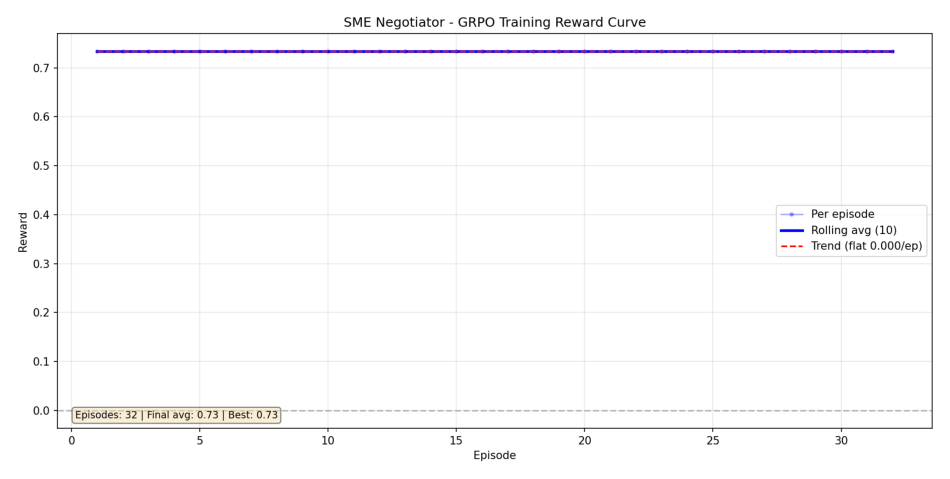

Episode reward log saved to /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episode_reward_log.json
Reward curve saved to /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/reward_curve.png


In [6]:
from pathlib import Path

episode_reward_log_path = Path(manifest["training"].get("episode_reward_log_path", manifest["training"]["reward_log_path"]))
output_dir = Path(manifest["plan"]["paths"]["output_dir"])

# Use plot_rewards from the package
plot_rewards(episode_reward_log_path, output_dir / "reward_curve.png")

# Also display inline
import matplotlib.pyplot as plt
from matplotlib.image import imread

img = imread(str(output_dir / "reward_curve.png"))
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(img)
ax.axis("off")
plt.show()

print(f"Episode reward log saved to {episode_reward_log_path}")
print(f"Reward curve saved to {output_dir / 'reward_curve.png'}")


## 7. Exported Artifacts

The simple script writes a run manifest plus the main training artifacts.

In [7]:
training_artifacts = manifest["training"]
print(f"Checkpoint path: {training_artifacts['checkpoint_path']}")
print(f"Episode reward log path: {training_artifacts.get('episode_reward_log_path', training_artifacts['reward_log_path'])}")
print(f"Trainer reward log path: {training_artifacts.get('trainer_reward_log_path', training_artifacts['reward_log_path'])}")
print(f"Reward curve path: {training_artifacts['reward_curve_path']}")
print(f"Training dashboard path: {training_artifacts['training_dashboard_path']}")
print(f"Run manifest path: {manifest['manifest_path']}")

manifest


Checkpoint path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/final-grpo-model
Episode reward log path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episode_reward_log.json
Trainer reward log path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/reward_log.json
Reward curve path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/reward_curve.png
Training dashboard path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/training_dashboard.png
Run manifest path: /kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/run_manifest.json


{'run_type': 'simple_grpo_training',
 'plan': {'profile': 'tiny',
  'task': {'model_name': 'Qwen/Qwen3-0.6B',
   'task_name': 'liquidity-correlation-hard',
   'difficulty': 'hard',
   'total_periods': 2,
   'seed_base': 1000},
  'training': {'runtime_backend': 'environment',
   'num_samples': 8,
   'max_steps': 4,
   'max_episode_steps': 8,
   'num_generations': 4,
   'gradient_accumulation_steps': 4,
   'learning_rate': 5e-06,
   'max_completion_length': 256,
   'use_vllm': True,
   'vllm_mode': 'colocate',
   'vllm_gpu_memory_utilization': 0.5,
   'vllm_max_model_length': 2048,
   'rubric_weight': 0.0},
  'paths': {'output_dir': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple',
   'final_checkpoint': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/final-grpo-model',
   'reward_log': '/kaggle/working/OpenEnv_SME_Negotiator-2.o/outputs/grpo_sme_liquidity_simple/episode_reward_log.json',
   'episode_reward_log': '/kaggle/workin